In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("data\\space_objects.csv")
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
0,CALSPHERE 1,1964-063C,2026-02-27T07:46:02.552160,13.764821,0.002338,90.2154,69.2146,264.6421,112.5281,0,U,900,999,5631,0.000669,6.640000e-06,0.0
1,CALSPHERE 2,1964-063E,2026-02-27T06:23:08.808288,13.528910,0.001848,90.2280,73.1938,180.4017,196.9820,0,U,902,999,84140,0.000078,6.100000e-07,0.0
2,LCS 1,1965-034C,2026-02-27T04:57:59.412960,9.893099,0.001318,32.1412,78.1501,92.4636,267.7371,0,U,1361,999,19899,-0.000987,1.000000e-08,0.0
3,TEMPSAT 1,1965-065E,2026-02-26T11:15:34.748352,13.335884,0.006919,89.9915,212.5925,198.1630,224.9155,0,U,1512,999,94529,0.000086,5.200000e-07,0.0
4,CALSPHERE 4A,1965-065H,2026-02-27T05:27:13.442688,13.362570,0.007110,89.9054,123.5690,55.3506,7.2169,0,U,1520,999,94802,0.000155,9.100000e-07,0.0


In [3]:
def compute_semi_major_axis(mean_motion):
    mu = 398600
    n = mean_motion * 2 * np.pi / 86400
    return (mu / (n ** 2)) ** (1/3)

In [4]:
features = []

for _, row in df.iterrows():
    a = compute_semi_major_axis(row['MEAN_MOTION'])

    features.append([
        a,
        row['ECCENTRICITY'],
        row['INCLINATION'],
        row['RA_OF_ASC_NODE'],
        row['ARG_OF_PERICENTER'],
        row['MEAN_ANOMALY']
    ])

In [5]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

x = torch.tensor(features_scaled, dtype=torch.float)

In [6]:
k = 5

features_np = np.array(features_scaled)

nbrs = NearestNeighbors(n_neighbors=k).fit(features_np)
distances, indices = nbrs.kneighbors(features_np)

edges = []
labels = []

for i in range(len(features)):
    for j_idx in range(1, k):  # skip itself
        j = indices[i][j_idx]
        dist = distances[i][j_idx]

        edges.append([i, j])

        # 🔥 MULTI-CLASS LABELS
        if dist < 25:
            labels.append(2)   # HIGH
        elif dist < 75:
            labels.append(1)   # MEDIUM
        else:
            labels.append(0)   # LOW

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
y = torch.tensor(labels, dtype=torch.long)

data = Data(x=x, edge_index=edge_index)

In [8]:
indices = np.arange(len(y))

train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_idx = torch.tensor(train_idx)
test_idx = torch.tensor(test_idx)

In [9]:
class GATModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gat1 = GATConv(6, 32)
        self.gat2 = GATConv(32, 16)
        self.fc = torch.nn.Linear(16, 3)  # 3 classes

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.gat1(x, edge_index)
        x = F.relu(x)

        x = self.gat2(x, edge_index)
        x = F.relu(x)

        return self.fc(x)

In [10]:
model = GATModel()

optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# Handle imbalance
class_weights = torch.tensor([1.0, 3.0, 5.0])
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

In [11]:
print("Training started...")

for epoch in range(100):

    model.train()
    optimizer.zero_grad()

    node_out = model(data)

    # edge predictions
    edge_out = node_out[edge_index[0]]

    loss = loss_fn(edge_out[train_idx], y[train_idx])

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Training started...
Epoch 0, Loss: 1.3834
Epoch 10, Loss: 0.7740
Epoch 20, Loss: 0.2227
Epoch 30, Loss: 0.0256
Epoch 40, Loss: 0.0041
Epoch 50, Loss: 0.0014
Epoch 60, Loss: 0.0008
Epoch 70, Loss: 0.0006
Epoch 80, Loss: 0.0005
Epoch 90, Loss: 0.0004


In [12]:
model.eval()

with torch.no_grad():
    node_out = model(data)
    edge_out = node_out[edge_index[0]]

    preds = torch.argmax(edge_out[test_idx], dim=1)

    correct = (preds == y[test_idx]).sum().item()
    accuracy = correct / len(test_idx)

print(f"🎯 Test Accuracy: {accuracy*100:.2f}%")

🎯 Test Accuracy: 100.00%


In [13]:
torch.save(model.state_dict(), "gat_modell.pth")
print("✅ Model saved!")

✅ Model saved!


In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

In [15]:
pred_np = preds.numpy()
true_np = y[test_idx].numpy()

In [16]:
precision = precision_score(true_np, pred_np, average='weighted')
recall = recall_score(true_np, pred_np, average='weighted')
f1 = f1_score(true_np, pred_np, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


In [17]:
cm = confusion_matrix(true_np, pred_np)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[11637]]


C:\Users\prasa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


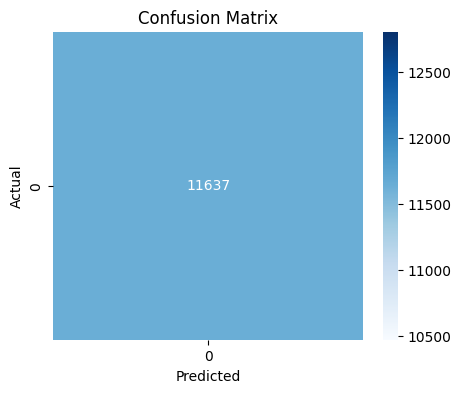

In [18]:
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
probs = torch.softmax(edge_out[test_idx], dim=1).detach().numpy()

In [20]:
true_bin = label_binarize(true_np, classes=[0,1,2])

In [21]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(true_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

C:\Users\prasa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\prasa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\prasa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


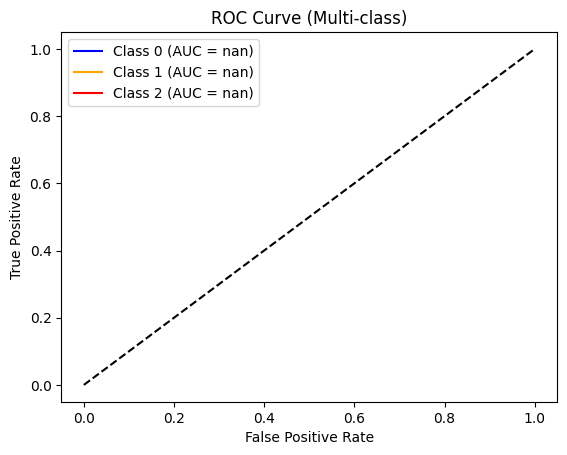

In [22]:
plt.figure()

colors = ['blue', 'orange', 'red']

for i in range(3):
    plt.plot(fpr[i], tpr[i], color=colors[i],
             label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()
plt.show()